# PYOD Example Use
TL;DR unsupervised methods rely heavily on quality data

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from typing import NamedTuple
import numpy as np
from functools import reduce

from time_series_generator import create_time_series_ensemble

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
from pyod.utils.utility import standardizer

In [2]:
class AnomalySet(NamedTuple):
    anomalies: pd.DataFrame
    title: str

In [3]:
def filter_to_sparse(anomalies: pd.DataFrame | pd.Series, sparse_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Normalize to DataFrame and filter to original sparse observation timestamps."""
    if isinstance(anomalies, pd.Series):
        anomalies = anomalies.to_frame()
    mask = anomalies.index.isin(sparse_index) & anomalies.astype(bool).any(axis=1)
    return anomalies[mask]

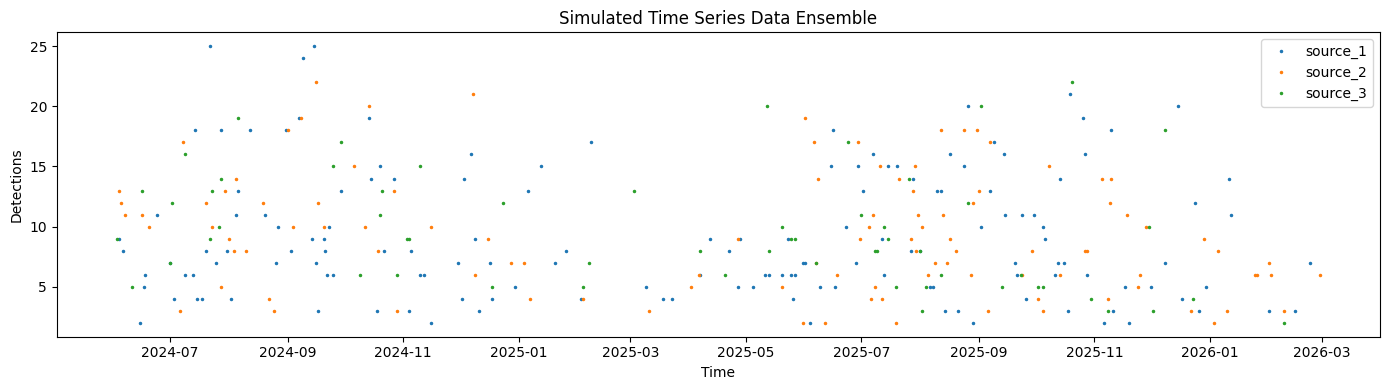

In [4]:
ts_raw = create_time_series_ensemble(
    start_date="2024-06-01",
    magnitude=15,    
    noise_scale=0.4, 
    floor=2,        # minimum 2 always present
    log_rates=[0.5, 0.3, 0.2],
    seasonal_cycles={1: 0.3, 7: 0.45, 365.25: 0.4},
    seed=int(time.time_ns()),
    y_label="source",
    plot=True,
)

In [5]:
source_cols = [col for col in ts_raw.columns if col != "time"]

ts_sparse = ts_raw.set_index("time")
ts_sparse.index = pd.DatetimeIndex(ts_sparse.index)

sparse_index = ts_sparse.index  # original uneven observation dates; used to filter anomalies back to real points

daily_index = pd.date_range(ts_sparse.index.min(), ts_sparse.index.max(), freq="D")

ts_daily = (
    ts_sparse
    .reindex(daily_index)
    .interpolate(method="time")
    .ffill()
    .bfill()
)
ts_daily.index.name = "time"

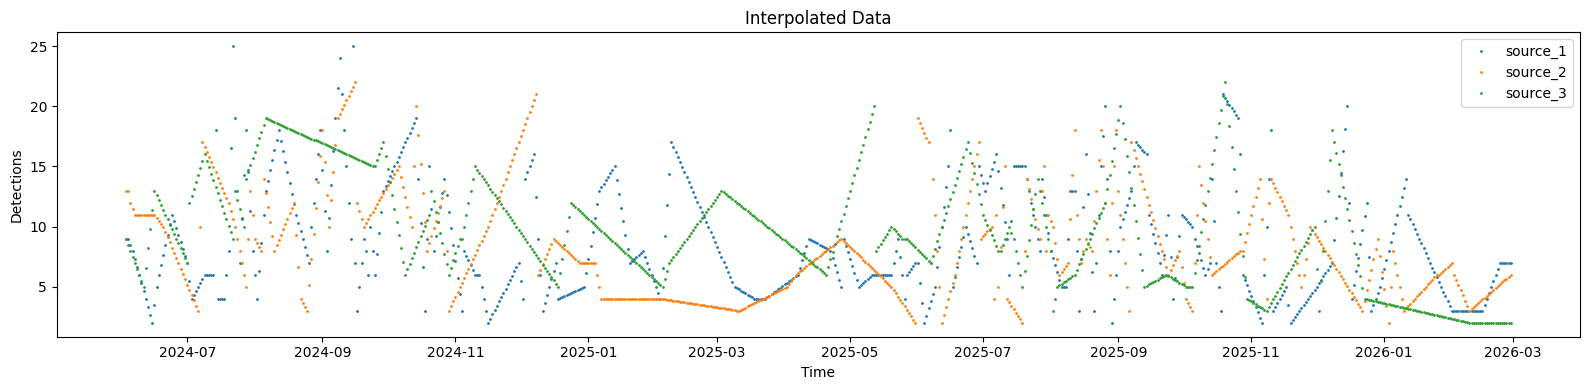

In [6]:
plt.figure(figsize=(16, 4))
for col in source_cols:
    plt.plot(ts_daily.index, ts_daily[col], ".", markersize=2, label=col)
plt.title("Interpolated Data")
plt.xlabel("Time")
plt.ylabel("Detections")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# 1. Use contamination parameter to control expected outlier proportion.
# 2. Use ensemble voting with a higher threshold (e.g., ≥3 detectors).
# 3. Use median absolute deviation (MAD) as a baseline for comparison.
# 4. Optionally, smooth the time series before detection (e.g., rolling mean).

def pyod_detect(model_cls, data, cols, contamination=0.05, **kwargs):
    out = pd.DataFrame(index=data.index, columns=cols)
    for col in cols:
        X = data[[col]].dropna().values
        idx = data[[col]].dropna().index
        X_std = standardizer(X)
        model = model_cls(contamination=contamination, **kwargs)
        model.fit(X_std)
        preds = pd.Series(model.labels_.astype(bool), index=idx)
        out.loc[idx, col] = preds
    return out

# Optionally smooth the time series before detection
def smooth_df(df, window=3):
    return df.rolling(window=window, min_periods=1, center=True).mean()

ts_sparse_smoothed = smooth_df(ts_sparse, window=3)
ts_daily_smoothed  = smooth_df(ts_daily, window=3)

iforest_anomalies = filter_to_sparse(pyod_detect(IForest, ts_daily_smoothed, source_cols, contamination=0.03), ts_sparse.index)
knn_anomalies     = filter_to_sparse(pyod_detect(KNN, ts_sparse_smoothed, source_cols, contamination=0.03, method='largest', n_neighbors=5), ts_sparse.index)
lof_anomalies     = filter_to_sparse(pyod_detect(LOF, ts_sparse_smoothed, source_cols, contamination=0.03, n_neighbors=9), ts_sparse.index)
ecod_anomalies    = filter_to_sparse(pyod_detect(ECOD, ts_daily_smoothed, source_cols, contamination=0.03), ts_sparse.index)

# Median Absolute Deviation baseline
def mad_outliers(df, cols, thresh=3.5):
    out = pd.DataFrame(False, index=df.index, columns=cols)
    for col in cols:
        x = df[col].dropna()
        med = x.median()
        mad = (np.abs(x - med)).median()
        score = np.abs(x - med) / (mad + 1e-8)
        out.loc[x.index, col] = score > thresh
    return out

mad_anomalies = filter_to_sparse(mad_outliers(ts_sparse_smoothed, source_cols), ts_sparse.index)

# Use ensemble voting with a higher threshold
def ensemble_anomalies(
    anomaly_sets: list[pd.DataFrame],
    min_votes: int = 2,
) -> pd.DataFrame:
    all_indices = anomaly_sets[0].index
    for df in anomaly_sets[1:]:
        all_indices = all_indices.union(df.index)

    all_columns = anomaly_sets[0].columns
    for df in anomaly_sets[1:]:
        all_columns = all_columns.union(df.columns)

    combined = sum(
        df.reindex(index=all_indices, columns=all_columns)
          .fillna(False)
          .astype(int)
        for df in anomaly_sets
    )
    return combined >= min_votes

vote_threshold_anomalies = ensemble_anomalies(
    [iforest_anomalies, knn_anomalies, lof_anomalies, ecod_anomalies, mad_anomalies],
    min_votes=3
)

for name, df in [
    ("IForest",   iforest_anomalies),
    ("KNN",       knn_anomalies),
    ("LOF",       lof_anomalies),
    ("ECOD",      ecod_anomalies),
    ("MAD",       mad_anomalies),
    ("Vote Threshold", vote_threshold_anomalies),
]:
    total = int(df.fillna(False).astype(int).sum().sum())
    print(f"{name:>16}: {total} flagged points")

         IForest: 24 flagged points
             KNN: 14 flagged points
             LOF: 15 flagged points
            ECOD: 24 flagged points
             MAD: 13 flagged points
  Vote Threshold: 9 flagged points


In [8]:
def vote_score_series(
    anomaly_sets: list[pd.DataFrame],
    source_cols: list[str],
) -> pd.DataFrame:
    all_indices = reduce(lambda a, b: a.union(b), [df.index for df in anomaly_sets])
    scores = pd.DataFrame(0, index=all_indices, columns=source_cols)
    for df in anomaly_sets:
        aligned = df.reindex(index=all_indices, columns=source_cols).fillna(False).astype(int)
        scores = scores + aligned
    return scores

def plot_anomalies(
    anomaly_sets: list[AnomalySet],
    source_cols: list[str],
    ts_sparse: pd.DataFrame,
    ts_daily: pd.DataFrame,
    use_interpolated: bool = False,
):
    plot_data = ts_daily if use_interpolated else ts_sparse
    fig, axes = plt.subplots(len(anomaly_sets), 1, figsize=(15, 4 * len(anomaly_sets)))
    for ax, aset in zip(axes, anomaly_sets):
        for col in source_cols:
            ax.plot(plot_data.index, plot_data[col], linewidth=0.8, label=col)
        for date in aset.anomalies[aset.anomalies.any(axis=1)].index:
            flagged_cols = aset.anomalies.loc[date]
            flagged_cols = flagged_cols[flagged_cols.astype(bool)].index
            for col in flagged_cols:
                y = ts_sparse.loc[date, col] if date in ts_sparse.index else plot_data.loc[date, col]
                if pd.isna(y):
                    continue
                ax.scatter(date, y, color="red", s=40, zorder=5)
        ax.set_title(aset.title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Detections")
        ax.legend()
    plt.tight_layout()
    plt.show()

def plot_ensemble_anomalies(
    ts_daily: pd.DataFrame,
    ts_sparse: pd.DataFrame,
    source_cols: list[str],
    vote_threshold_anomalies: pd.DataFrame,
    vote_lof_anomalies: pd.DataFrame,
):
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle("Ensemble Anomaly Detection", fontsize=12, fontweight="bold")
    plt.subplots_adjust(hspace=0.4)
    datasets = [
        ("Vote Threshold  (≥3 detectors)",    vote_threshold_anomalies),
        ("Vote LOF  (anomalous flag density)", vote_lof_anomalies),
    ]
    for ax, (title, data) in zip(axes, datasets):
        for col in source_cols:
            ax.plot(ts_daily.index, ts_daily[col], linewidth=0.8, alpha=0.5)
        flagged = data.fillna(False).astype(bool)
        for col in [c for c in source_cols if c in flagged.columns]:
            for date in flagged.index[flagged[col]]:
                y = ts_sparse.loc[date, col] if date in ts_sparse.index else ts_daily.loc[date, col]
                if pd.isna(y):
                    continue
                ax.scatter(date, y, color="red", s=40, zorder=5, marker="o")
        n = int(flagged.values.sum())
        ax.set_title(f"{title}  ({n} flags)", fontsize=9, loc="left")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_ylabel("Detections")
    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

In [9]:
vote_scores = vote_score_series(
    [iforest_anomalies, knn_anomalies, lof_anomalies, ecod_anomalies],
    source_cols=source_cols,
)
# Use LOF for voting anomaly detection on vote scores
vote_lof_anomalies = pyod_detect(LOF, vote_scores, source_cols, n_neighbors=5)

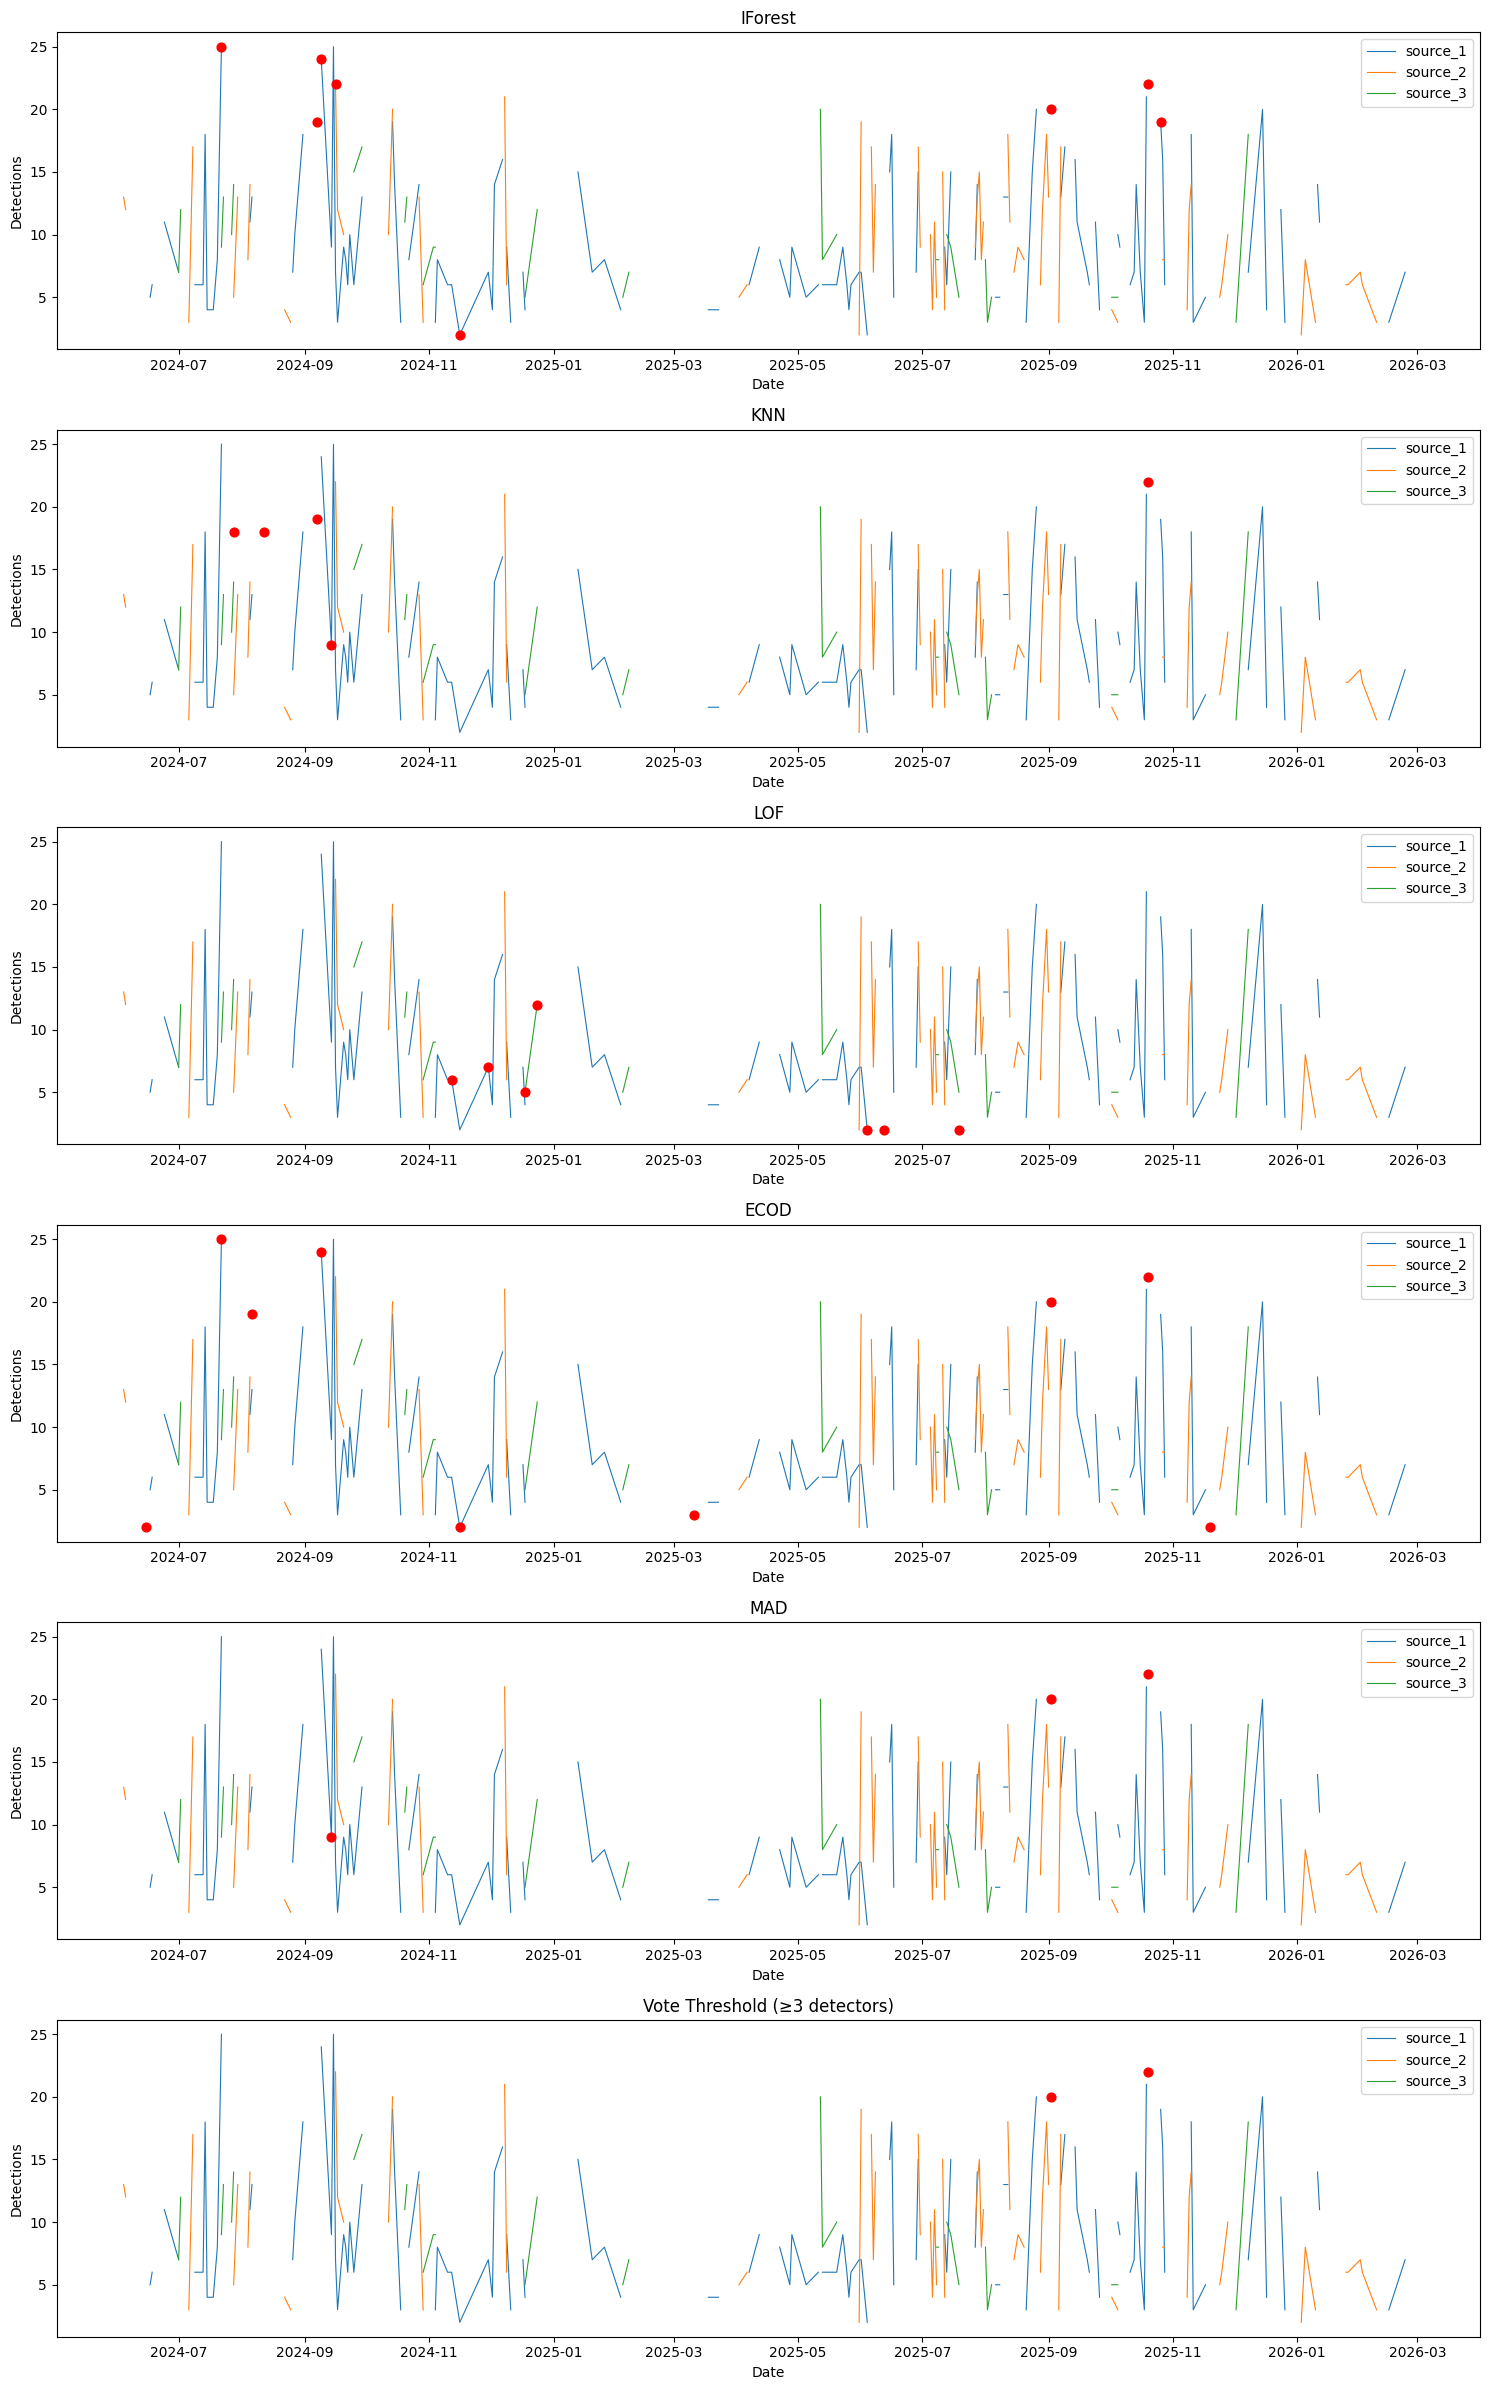

In [10]:
plot_anomalies(
    anomaly_sets=[
        AnomalySet(iforest_anomalies,   "IForest"),
        AnomalySet(knn_anomalies,       "KNN"),
        AnomalySet(lof_anomalies,       "LOF"),
        AnomalySet(ecod_anomalies,      "ECOD"),
        AnomalySet(mad_anomalies,       "MAD"),
        AnomalySet(vote_threshold_anomalies,  "Vote Threshold (≥3 detectors)"),
    ],
    source_cols=source_cols,
    ts_sparse=ts_sparse,
    ts_daily=ts_daily,
    use_interpolated=False,
)

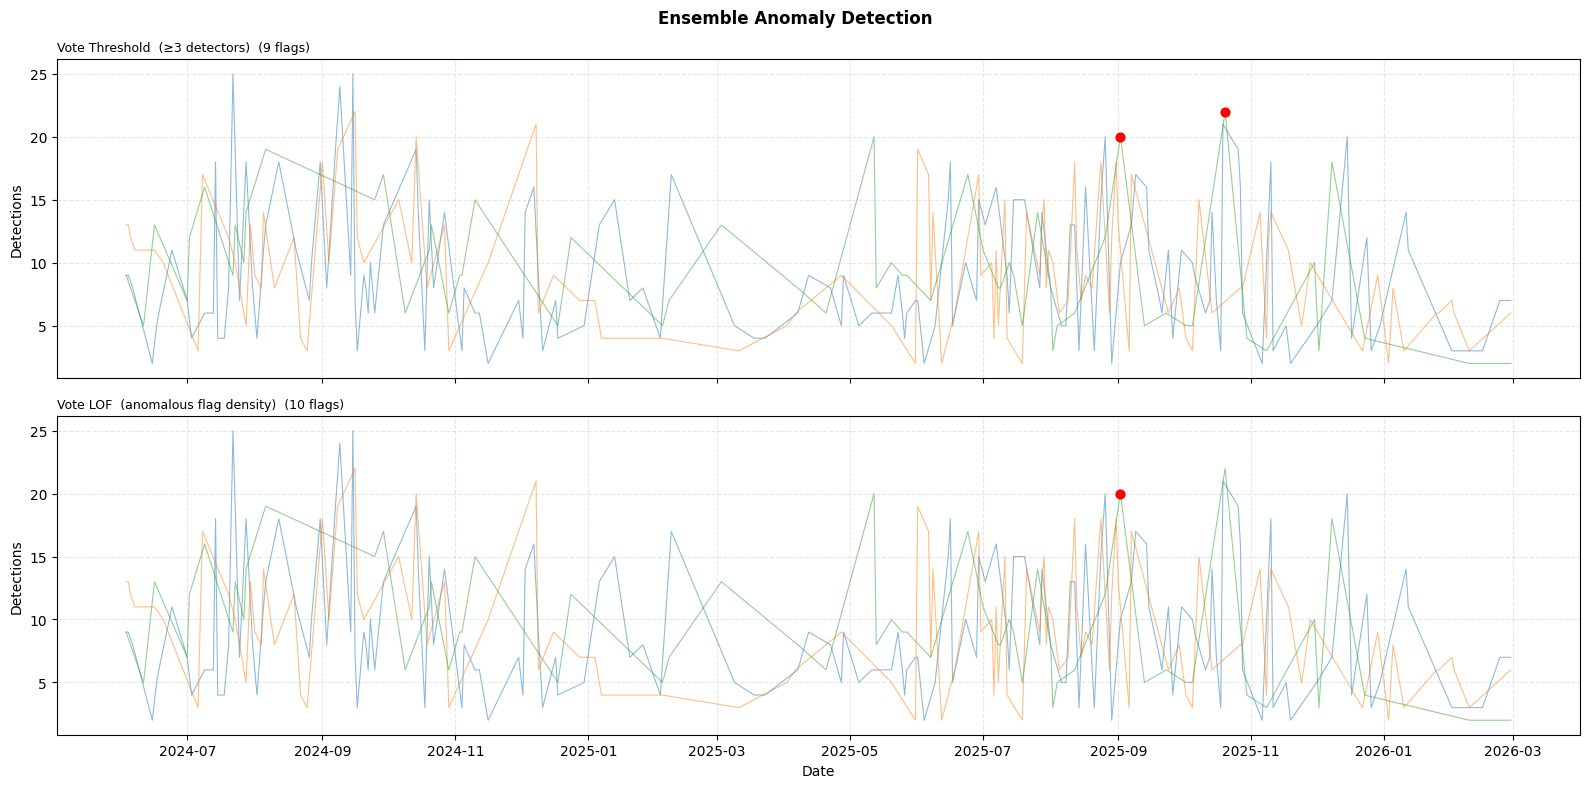

In [11]:
plot_ensemble_anomalies(
    ts_daily=ts_daily,
    ts_sparse=ts_sparse,
    source_cols=source_cols,
    vote_threshold_anomalies=vote_threshold_anomalies,
    vote_lof_anomalies=vote_lof_anomalies,
)